In [1]:
import pandas as pd

df = pd.read_csv("clean_crime_dataset.csv")

# Convert date & time
df['Date'] = pd.to_datetime(df['Date'])
df['Hour'] = pd.to_datetime(df['Time']).dt.hour

# Extract features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Weekday'] = df['Date'].dt.day_name()

print(df.head())

        Date Crime_Type  Location   Latitude  Longitude   Time         Area  \
0 2023-10-17   Burglary    Market  16.506181  80.692607  03:01       Guntur   
1 2022-05-23      Fraud    Street  16.559799  80.639799  23:06  Mangalagiri   
2 2022-02-02    Assault    Market  16.473403  80.573399  00:05   Vijayawada   
3 2023-07-29      Fraud  Bus Stop  16.458713  80.679926  06:45       Guntur   
4 2023-04-05      Theft    Market  16.540167  80.656211  18:17  Mangalagiri   

   Hour  Year  Month  Day    Weekday  
0     3  2023     10   17    Tuesday  
1    23  2022      5   23     Monday  
2     0  2022      2    2  Wednesday  
3     6  2023      7   29   Saturday  
4    18  2023      4    5  Wednesday  


C:\Users\pujas\AppData\Local\Temp\ipykernel_10500\680204244.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Hour'] = pd.to_datetime(df['Time']).dt.hour


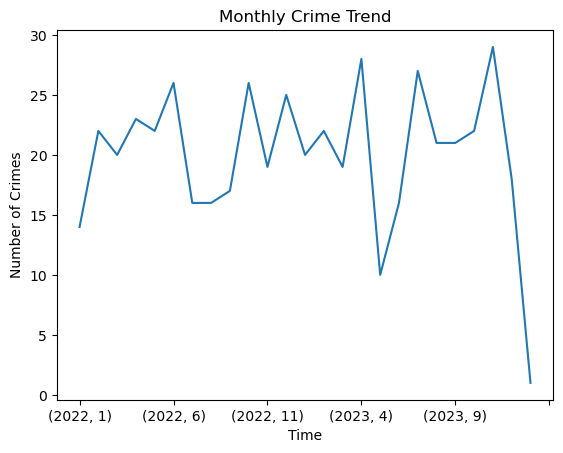

In [2]:
import matplotlib.pyplot as plt

monthly_trend = df.groupby(['Year', 'Month']).size()

monthly_trend.plot(kind='line')
plt.title("Monthly Crime Trend")
plt.xlabel("Time")
plt.ylabel("Number of Crimes")
plt.show()

In [3]:
from sklearn.cluster import DBSCAN
import numpy as np

coords = df[['Latitude', 'Longitude']].values

# DBSCAN clustering
db = DBSCAN(eps=0.01, min_samples=5).fit(coords)

df['Cluster'] = db.labels_

print(df[['Latitude','Longitude','Cluster']].head())

    Latitude  Longitude  Cluster
0  16.506181  80.692607        0
1  16.559799  80.639799        0
2  16.473403  80.573399        0
3  16.458713  80.679926        0
4  16.540167  80.656211        0


In [7]:
%pip install folium


  Using cached folium-0.20.0-py2.py3-none-any.whl.metadata (4.2 kB)
  Using cached branca-0.8.2-py3-none-any.whl.metadata (1.7 kB)
Using cached folium-0.20.0-py2.py3-none-any.whl (113 kB)
Using cached branca-0.8.2-py3-none-any.whl (26 kB)
Note: you may need to restart the kernel to use updated packages.


In [8]:
import folium
from folium.plugins import HeatMap

# 1. Clean data: Ensure there are no missing coordinates for the heatmap
# This prevents errors during the mean calculation or map rendering
data_clean = df[['Latitude', 'Longitude']].dropna()

if not data_clean.empty:
    # 2. Calculate center safely
    map_center = [data_clean['Latitude'].mean(), data_clean['Longitude'].mean()]
    
    # 3. Initialize map
    m = folium.Map(location=map_center, zoom_start=12)
    
    # 4. Create and add the HeatMap
    # HeatMap expects a list of points: [[lat, lon], [lat, lon], ...]
    heat_data = data_clean.values.tolist()
    HeatMap(heat_data).add_to(m)
    
    # Display the map
    display(m)
else:
    print("Warning: DataFrame is empty or contains only null coordinates.")


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Encode categorical data
le = LabelEncoder()
df['Crime_Type'] = le.fit_transform(df['Crime_Type'])
df['Location'] = le.fit_transform(df['Location'])
df['Area'] = le.fit_transform(df['Area'])

# Features & target
X = df[['Location', 'Area', 'Hour']]
y = df['Crime_Type']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Accuracy
print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.12


In [10]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[2 7 6 3 3]
 [1 3 5 4 4]
 [4 7 6 2 3]
 [5 3 4 0 4]
 [7 4 8 4 1]]
              precision    recall  f1-score   support

           0       0.11      0.10      0.10        21
           1       0.12      0.18      0.15        17
           2       0.21      0.27      0.24        22
           3       0.00      0.00      0.00        16
           4       0.07      0.04      0.05        24

    accuracy                           0.12       100
   macro avg       0.10      0.12      0.11       100
weighted avg       0.10      0.12      0.11       100



In [11]:
sample = [[1, 2, 18]]  # Example: Location, Area, Hour
prediction = model.predict(sample)

print("Predicted Crime:", le.inverse_transform(prediction))

Predicted Crime: ['Guntur']


c:\Users\pujas\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [12]:
area_risk = df.groupby('Area').size().reset_index(name='Crime_Count')

def risk_label(x):
    if x > 100:
        return "High 🔴"
    elif x > 50:
        return "Medium 🟠"
    else:
        return "Low 🟢"

area_risk['Risk_Level'] = area_risk['Crime_Count'].apply(risk_label)

print(area_risk)

   Area  Crime_Count Risk_Level
0     0          115     High 🔴
1     1          123     High 🔴
2     2          152     High 🔴
3     3          110     High 🔴


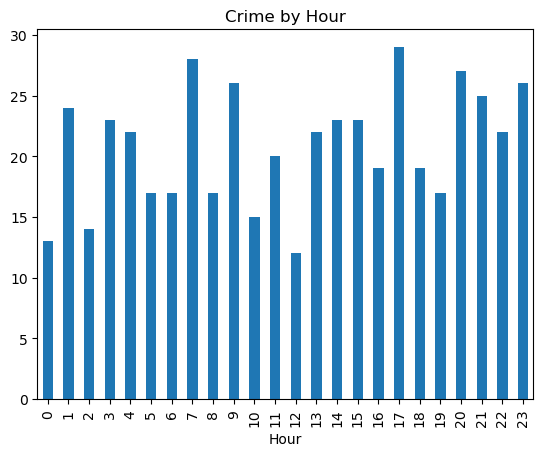

In [13]:
hourly = df.groupby('Hour').size()

hourly.plot(kind='bar')
plt.title("Crime by Hour")
plt.show()